In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input, Embedding

In [2]:
# Generate sine wave data
t = np.linspace(0 , 100 , 1000)
data = np.sin(t)
data

## Creating sequence
def create_dataset(data, time_step=20):
    X , y = [] , []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X) , np.array(y)
X , y = create_dataset(data)
X.shape

(980, 20)

In [3]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X.shape

(980, 20, 1)

In [4]:
# Train test split
train_size = int(len(X) * 0.8)

In [7]:
# Regression Accuracy
def regression_accuracy(y_true, y_pred):
    return tf.reduce_mean(tf.cast(tf.abs(y_true - y_pred) < 0.1, tf.float32))

# How your function works
# tf.abs(y_true - y_pred): Calculates the distance between the prediction and reality.

# < 0.1: This is your "Margin of Error." You are deciding that being off by 0.09 is a "Win," but being off by 0.11 is a "Loss."

# tf.cast(..., tf.float32): Converts those True values to 1.0 and False values to 0.0.

# tf.reduce_mean(...): Averages those 1s and 0s to give you a percentage (e.g., 0.85 accuracy).

In [5]:
# Model
model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    SimpleRNN(50, activation='tanh'),
    Dense(1)
])

In [8]:
# Model Compile
model.compile(optimizer='adam', loss='mse', metrics=[regression_accuracy])

In [9]:
# Training with validation
history = model.fit(
    X[:train_size], 
    y[:train_size], 
    epochs=20, 
    validation_data=(X[train_size:], y[train_size:]))

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0664 - regression_accuracy: 0.0911 - val_loss: 0.0094 - val_regression_accuracy: 0.2040
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - regression_accuracy: 0.1320 - val_loss: 0.0012 - val_regression_accuracy: 0.2040
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.2469e-04 - regression_accuracy: 0.1297 - val_loss: 6.2513e-04 - val_regression_accuracy: 0.2115
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0533e-04 - regression_accuracy: 0.1336 - val_loss: 4.1199e-04 - val_regression_accuracy: 0.2154
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6568e-04 - regression_accuracy: 0.1279 - val_loss: 3.6253e-04 - val_regression_accuracy: 0.2164
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8543e-04 - regression_accuracy: 0.1332 - val_loss: 2.5624e-04 - val_regression_accuracy: 0.2174
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2132e-04 - regressi

In [17]:
# Evaluate 
test_loss , test_accuracy = model.evaluate(X[:train_size], y[:train_size])

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6877e-05 - regression_accuracy: 0.1954 
Test Loss: 0.0000
Test Accuracy: 0.1954


In [20]:
import pandas as pd

# Temperature Data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
data = pd.read_csv(url)
data.tail()

,Date,Temp
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7
3649,1990-12-31,13.0


In [21]:
# Normalizing the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data["Temp"] = scaler.fit_transform(data[["Temp"]])
data.head()

,Date,Temp
0,1981-01-01,0.787072
1,1981-01-02,0.680608
2,1981-01-03,0.714829
3,1981-01-04,0.555133
4,1981-01-05,0.600760


In [22]:
# Creating Sequences
def create_dataset(data , time_step=20):
    X , y = [] , []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X) , np.array(y)

In [23]:
# Assigning X and y
X , y = create_dataset(data["Temp"].values)
X = X.reshape(X.shape[0], X.shape[1], 1)

X_train , y_train , X_test , y_test = X[:train_size] , y[:train_size] , X[train_size:] , y[train_size:]

In [29]:
model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    SimpleRNN(64, return_sequences=True, activation='tanh'),
    SimpleRNN(64, return_sequences=True, activation='tanh'),
    SimpleRNN(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 20, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 20, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,389 (189.02 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,260 (126.02 KB)

In [30]:
# Train data
model.compile(optimizer='adam', loss='mse', metrics=[regression_accuracy])

# Fit data
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0448 - regression_accuracy: 0.3677 - val_loss: 0.0148 - val_regression_accuracy: 0.5965
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0197 - regression_accuracy: 0.3634 - val_loss: 0.0179 - val_regression_accuracy: 0.5247
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0156 - regression_accuracy: 0.3697 - val_loss: 0.0107 - val_regression_accuracy: 0.6559
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0122 - regression_accuracy: 0.3544 - val_loss: 0.0099 - val_regression_accuracy: 0.6673
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0126 - regression_accuracy: 0.3564 - val_loss: 0.0097 - val_regression_accuracy: 0.6651
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0117 - regression_accuracy: 0.3568 - val_loss: 0.0123 - val_regression_accuracy: 0.5954
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0119 - regression_accuracy: 0.3551 - val_loss: 0.0124 - 

In [31]:
# Evaluate
test_loss , test_accuracy = model.evaluate(X_train, y_train)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0089 - regression_accuracy: 0.5827
Test Loss: 0.0089
Test Accuracy: 0.5827


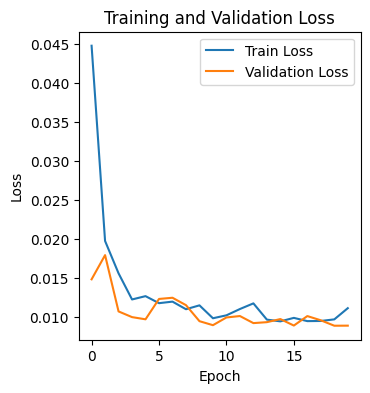

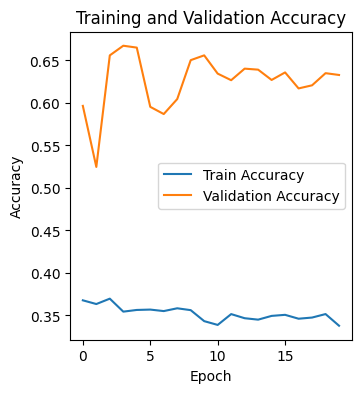

In [37]:
## Graphs too make a clearer picture of the training process

# Loss vs Epochs
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Accuracy vs Epochs
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 2)
plt.plot(history.history['regression_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_regression_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [52]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input, Embedding

In [53]:
# Load Data
vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [68]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    SimpleRNN(64, return_sequences=False, activation='tanh'),
    Dense(1, activation='sigmoid')
])
model.summary()

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6351 - loss: 0.6187 - val_accuracy: 0.7224 - val_loss: 0.5437
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8361 - loss: 0.3814 - val_accuracy: 0.8286 - val_loss: 0.4180
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8103 - loss: 0.4087 - val_accuracy: 0.7146 - val_loss: 0.5744
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8026 - loss: 0.4315 - val_accuracy: 0.7068 - val_loss: 0.6934
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8723 - loss: 0.3004 - val_accuracy: 0.6362 - val_loss: 0.7455


In [72]:
# Evaluation
test_loss , test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6278 - loss: 0.7449
Test Loss: 0.7449
Test Accuracy: 0.6278
